# PtychoPINN Modeling Analysis

This notebook extracts empirical coefficients from `modeling_exp/<GPU>/R*/bs1024.log` and `bs1024_power.csv`.

Modeling targets:

- I/O latency: `T_IO ≈ group_coords + write_image_tensors`
- Inference latency, batch model: `T_infer(D,B,G) ≈ A_batch(G,B) + K(G,B) * ceil(S(D) / B)`
- Inference latency, FLOPs model: `T_infer(D,B,G) ≈ A_flops(G,B) + FLOPs(D) / P_eff(G,B)`
- Matched power/energy: power CSV recorded during the main `load_and_predict` timing window

Notation:

- `R`: raw images, from folder name like `R26000`
- `V`: valid/potential central scan points, parsed from `Processing ... potential central points`
- `S`: grouped NN samples, parsed from `Dataset length`
- `B`: batch size, parsed from `bs1024.log`
- `D`: input dataset
- `G`: GPU or accelerator type, e.g. `A100`, `H200`, `MI300A`
- `N`: diffraction image resolution; the current measured synthetic sweep uses baseline `N0=64`
- `C`: grouped input channels/images; current PtychoPINN config uses `C=4`
- `F_sample(N)`: FLOPs per grouped sample for the fixed PtychoPINN network at resolution `N`
- `FLOPs(D,N)`: total neural-network work for dataset `D`, estimated as `S(D) * F_sample(N)`
- `A_batch(G,B)`: fixed inference overhead in the batch model, seconds
- `K(G,B)`: incremental inference time per NN batch, seconds/batch
- `A_flops(G,B)`: fixed inference overhead in the FLOPs model, seconds
- `P_eff(G,B)`: effective achieved throughput, FLOPs/second; this is fitted from measurements, not theoretical peak GPU FLOPs

Important: in the synthetic sweep, `V` and `S` are nearly identical by construction, so the joint fit `alpha*V + beta*S` is collinear. We estimate `alpha` and the write coefficient from their measured substeps separately. For resolution-aware I/O, the write coefficient is normalized to tensor elements: `T_write(D,G,N) ≈ beta_pixel(G) * S(D) * C * N^2`.


### FLOPs Calculation for PtychoPINN Inference

For inference modeling, the total neural-network work for a dataset `D` at image resolution `N` is estimated as:

`F(D,N) = S(D) * F_sample(N)`

where:

`S(D)` = number of grouped samples actually sent into the neural network  
`F_sample(N)` = FLOPs per grouped sample at resolution `N`

For the current measured baseline:

input shape per grouped sample = `(C, N0, N0) = (4, 64, 64)`  
`C = 4` grouped diffraction images  
`N0 = 64` baseline image resolution

Using the current model configuration:

`n_filters_scale = 2`  
`object_big = True`  
`probe_big = True`  
`cbam_encoder = True`

The baseline forward pass operation count is approximately:

`835,149,312 MACs per grouped sample` at `N=64`

Using the standard convention:

`1 MAC = 1 multiply + 1 add = 2 FLOPs`

so:

`F_sample(64) = 835,149,312 * 2 FLOPs`  
`F_sample(64) = 1,670,298,624 FLOPs`  
`F_sample(64) ≈ 1.670 GFLOPs per grouped sample`

For resolution-aware modeling we use:

`F(D,N) = S(D) * F_sample(N)`

Current architecture-level estimates:

| N | F_sample(N) |
|---:|---:|
| 32 | unsupported by current decoder; requires a separate architecture/FLOPs count |
| 64 | 1.670 GFLOPs/sample |
| 128 | 3.774 GFLOPs/sample |
| 256 | 12.002 GFLOPs/sample |

The measured coefficients in this notebook are fitted from `N=64` runs. For `N=128` or `N=256`, the FLOPs model can estimate work using `F_sample(N)`, but the most accurate latency model should re-fit `P_eff(G,B,N)` with measurements at that resolution.


In [ ]:
from pathlib import Path
import csv
import math
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 140)

cwd = Path.cwd()
if cwd.name == "modeling_exp":
    MODELING_ROOT = cwd
elif (cwd / "modeling_exp").exists():
    MODELING_ROOT = cwd / "modeling_exp"
else:
    MODELING_ROOT = Path("/home/zhong.zheng/PtychoPINN/modeling_exp")

BATCH_SIZE_DEFAULT = 1024
BASELINE_C = 4
BASELINE_N = 64
F_SAMPLE_GFLOPS_BY_N = {
    32: np.nan,   # Current PtychoPINN decoder does not support N < 64 without architecture changes.
    64: 1.670,
    128: 3.774,
    256: 12.002,
}
F_SAMPLE_GFLOPS = F_SAMPLE_GFLOPS_BY_N[BASELINE_N]
MODELING_ROOT


In [ ]:
LOG_PATTERNS = {
    "valid_points": re.compile(r"Processing (\d+) potential central points"),
    "dataset_length": re.compile(r"Dataset length: (\d+)"),
    "group_coords_s": re.compile(r"memory_map_data dataset \d+ group coords: ([0-9.]+) s"),
    "write_image_tensors_s": re.compile(r"memory_map_data dataset \d+ write image tensors: ([0-9.]+) s"),
    "load_diff3d_s": re.compile(r"memory_map_data dataset \d+ load diff3d: ([0-9.]+) s"),
    "dataset_init_s": re.compile(r"__init__ total: ([0-9.]+) s"),
    "model_load_s": re.compile(r"Model load time: ([0-9.]+)"),
    "data_load_s": re.compile(r"Data load time: ([0-9.]+)"),
    "inference_s": re.compile(r"Total inference time: ([0-9.]+)"),
    "assembly_s": re.compile(r"Total assembly time: ([0-9.]+)"),
}

def last_match(text, key, cast=float):
    matches = LOG_PATTERNS[key].findall(text)
    if not matches:
        return np.nan
    return cast(matches[-1])

def parse_log(log_path: Path):
    text = log_path.read_text(encoding="utf-8", errors="replace")
    dataset_dir = log_path.parent
    gpu = dataset_dir.parent.name
    dataset = dataset_dir.name
    raw_match = re.fullmatch(r"R(\d+)", dataset)
    raw_images = int(raw_match.group(1)) if raw_match else np.nan
    batch_match = re.search(r"bs(\d+)", log_path.name)
    batch_size = int(batch_match.group(1)) if batch_match else BATCH_SIZE_DEFAULT
    return {
        "gpu": gpu,
        "dataset": dataset,
        "raw_images": raw_images,
        "batch_size": batch_size,
        "valid_points": last_match(text, "valid_points", int),
        "grouped_samples": last_match(text, "dataset_length", int),
        "group_coords_s": last_match(text, "group_coords_s"),
        "write_image_tensors_s": last_match(text, "write_image_tensors_s"),
        "load_diff3d_s": last_match(text, "load_diff3d_s"),
        "dataset_init_s": last_match(text, "dataset_init_s"),
        "model_load_s": last_match(text, "model_load_s"),
        "data_load_s": last_match(text, "data_load_s"),
        "inference_s": last_match(text, "inference_s"),
        "assembly_s": last_match(text, "assembly_s"),
        "log_file": str(log_path),
    }

def parse_power(power_path: Path):
    if not power_path.exists():
        return {}
    rows = []
    with power_path.open(newline="", encoding="utf-8") as handle:
        reader = csv.DictReader(handle)
        power_cols = [c for c in (reader.fieldnames or []) if c.endswith("Power(W)")]
        if not power_cols:
            return {"power_csv": str(power_path)}
        power_col = power_cols[0]
        for row in reader:
            try:
                t = float(row["Time(S)"])
                p = float(row[power_col])
            except (KeyError, TypeError, ValueError):
                continue
            if math.isnan(t) or math.isnan(p):
                continue
            rows.append((t, p))
    if not rows:
        return {"power_csv": str(power_path)}
    times = np.array([r[0] for r in rows], dtype=float)
    powers = np.array([r[1] for r in rows], dtype=float)
    energy_j = float(np.trapz(powers, times)) if len(rows) > 1 else 0.0
    return {
        "power_duration_s": float(times[-1]),
        "power_avg_w": float(powers.mean()),
        "power_min_w": float(powers.min()),
        "power_max_w": float(powers.max()),
        "power_energy_j": energy_j,
        "power_samples": int(len(rows)),
        "power_csv": str(power_path),
    }

records = []
for log_path in sorted(MODELING_ROOT.glob("*/R*/bs*.log")):
    rec = parse_log(log_path)
    power_path = log_path.with_name(log_path.name.replace(".log", "_power.csv"))
    rec.update(parse_power(power_path))
    records.append(rec)

df = pd.DataFrame(records).sort_values(["gpu", "raw_images", "batch_size"]).reset_index(drop=True)
df["num_batches"] = np.ceil(df["grouped_samples"] / df["batch_size"]).astype("Int64")
df["image_resolution"] = BASELINE_N
df["input_channels"] = BASELINE_C
df["F_sample_gflops"] = F_SAMPLE_GFLOPS
df["total_gflops"] = df["grouped_samples"] * df["F_sample_gflops"]
df["io_core_s"] = df["group_coords_s"] + df["write_image_tensors_s"]
df["top_level_s"] = df["model_load_s"] + df["data_load_s"] + df["inference_s"] + df["assembly_s"]
df["core_latency_s"] = df["data_load_s"] + df["inference_s"]
df["raw_to_grouped_ratio"] = df["raw_images"] / df["grouped_samples"]
df["grouped_per_raw"] = df["grouped_samples"] / df["raw_images"]
df["alpha_group_us_per_valid"] = 1e6 * df["group_coords_s"] / df["valid_points"]
df["beta_write_us_per_grouped"] = 1e6 * df["write_image_tensors_s"] / df["grouped_samples"]
df["beta_write_s_per_element"] = df["write_image_tensors_s"] / (df["grouped_samples"] * BASELINE_C * BASELINE_N**2)
df["beta_write_ns_per_element"] = 1e9 * df["beta_write_s_per_element"]
df["gamma_io_us_per_grouped"] = 1e6 * df["io_core_s"] / df["grouped_samples"]

print(f"Loaded {len(df)} runs from {MODELING_ROOT}")
df.head()


## Raw Extracted Runs

Each row is one GPU/dataset/batch run. `io_core_s` is the simplified I/O model target; `inference_s` is the NN latency target.

In [65]:
cols = [
    "gpu", "dataset", "raw_images", "valid_points", "grouped_samples", "batch_size", "num_batches", "total_gflops",
    "group_coords_s", "write_image_tensors_s", "io_core_s", "data_load_s", "inference_s", "assembly_s",
    "model_load_s", "top_level_s", "power_duration_s", "power_avg_w", "power_energy_j",
]
df[cols].round(4)

,gpu,dataset,raw_images,valid_points,grouped_samples,batch_size,num_batches,total_gflops,group_coords_s,write_image_tensors_s,io_core_s,data_load_s,inference_s,assembly_s,model_load_s,top_level_s,power_duration_s,power_avg_w,power_energy_j
0,A100,R1000,1000,784,784,1024,1,1309.28,0.1001,0.0306,0.1307,0.1814,0.4004,0.0292,0.9459,1.5569,1.83,37.4455,69.1648
1,A100,R2000,2000,1521,1521,1024,2,2540.07,0.1966,0.0542,0.2507,0.3162,0.4378,0.0343,0.9808,1.7691,2.23,40.0085,87.6740
2,A100,R4000,4000,3080,3080,1024,4,5143.60,0.3973,0.1015,0.4988,0.5996,0.5766,0.0366,1.3399,2.5527,3.04,49.1071,151.6790
3,A100,R8000,8000,6320,6320,1024,7,10554.40,0.8211,0.2044,1.0255,1.1748,0.7584,0.0358,1.3405,3.3094,4.03,52.2195,214.5330
4,A100,R12000,12000,9604,9604,1024,10,16038.68,1.2261,0.3179,1.5440,1.7604,0.9427,0.0429,0.9659,3.7119,4.63,59.7660,283.1777
5,A100,R16000,16000,12656,12656,1024,13,21135.52,1.6276,0.4493,2.0769,2.3586,1.1254,0.0460,0.9889,4.5189,5.83,60.1155,347.9336
6,A100,R20000,20000,16002,16002,1024,16,26723.34,2.0737,0.5872,2.6610,2.9769,1.3152,0.0497,0.9854,5.3271,7.03,58.7695,419.4980
7,A100,R26000,26000,20880,20880,1024,21,34869.60,2.8770,0.6719,3.5488,3.9503,1.6159,0.0687,0.9780,6.6129,8.63,66.8987,586.6918
8,B200,R1000,1000,784,784,1024,1,1309.28,0.0513,0.0935,0.1447,0.2119,0.5704,0.0480,1.1036,1.9339,2.26,192.0008,428.2460
9,B200,R2000,2000,1521,1521,1024,2,2540.07,0.1000,0.1713,0.2713,0.3398,0.6033,0.0694,1.2332,2.2456,2.66,194.0120,509.9620


## Dataset Geometry Ratios

These synthetic datasets should have roughly stable `S/R` and `V/R`. This allows estimating from raw input image count when grouped sample count is not known yet.

In [66]:
ratio_summary = df.groupby("gpu").agg(
    runs=("dataset", "count"),
    grouped_per_raw_mean=("grouped_per_raw", "mean"),
    grouped_per_raw_std=("grouped_per_raw", "std"),
    raw_to_grouped_mean=("raw_to_grouped_ratio", "mean"),
    valid_per_raw_mean=("valid_points", lambda s: float((s / df.loc[s.index, "raw_images"]).mean())),
).reset_index()
ratio_summary.round(4)

,gpu,runs,grouped_per_raw_mean,grouped_per_raw_std,raw_to_grouped_mean,valid_per_raw_mean
0,A100,8,0.7874,0.0153,1.2705,0.7874
1,B200,8,0.7874,0.0153,1.2705,0.7874
2,H200,8,0.7874,0.0153,1.2705,0.7874
3,MI300A,8,0.7874,0.0153,1.2705,0.7874
4,MI300X,8,0.7874,0.0153,1.2705,0.7874
5,Max,8,0.7874,0.0153,1.2705,0.7874


## I/O Coefficients

Substep coefficients:

- `alpha ≈ group_coords_s / V`
- `beta ≈ write_image_tensors_s / S`
- `gamma ≈ (group_coords_s + write_image_tensors_s) / S`

For synthetic inputs, `V≈S`, so `gamma` is often the most useful single I/O coefficient.

In [ ]:
io_coeff_summary = df.groupby("gpu").agg(
    runs=("dataset", "count"),
    alpha_group_us_per_valid_mean=("alpha_group_us_per_valid", "mean"),
    alpha_group_us_per_valid_std=("alpha_group_us_per_valid", "std"),
    beta_write_us_per_grouped_mean=("beta_write_us_per_grouped", "mean"),
    beta_write_us_per_grouped_std=("beta_write_us_per_grouped", "std"),
    beta_write_ns_per_element_mean=("beta_write_ns_per_element", "mean"),
    beta_write_ns_per_element_std=("beta_write_ns_per_element", "std"),
    gamma_io_us_per_grouped_mean=("gamma_io_us_per_grouped", "mean"),
    gamma_io_us_per_grouped_std=("gamma_io_us_per_grouped", "std"),
).reset_index()
io_coeff_summary.round(3)


In [68]:
def linear_fit(x, y, intercept=True):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    mask = np.isfinite(x) & np.isfinite(y)
    x = x[mask]
    y = y[mask]
    if len(x) == 0:
        return {"intercept": np.nan, "slope": np.nan, "r2": np.nan, "n": 0}
    if intercept:
        X = np.column_stack([np.ones_like(x), x])
        coeff, *_ = np.linalg.lstsq(X, y, rcond=None)
        yhat = X @ coeff
        b0, b1 = coeff
    else:
        b1 = float(np.dot(x, y) / np.dot(x, x)) if np.dot(x, x) else np.nan
        b0 = 0.0
        yhat = b1 * x
    ss_res = float(np.sum((y - yhat) ** 2))
    ss_tot = float(np.sum((y - y.mean()) ** 2))
    r2 = 1.0 - ss_res / ss_tot if ss_tot > 0 else np.nan
    return {"intercept": float(b0), "slope": float(b1), "r2": r2, "n": int(len(x))}

io_fits = []
for gpu, group in df.groupby("gpu"):
    fit = linear_fit(group["grouped_samples"], group["io_core_s"], intercept=True)
    io_fits.append({
        "gpu": gpu,
        "io_intercept_s": fit["intercept"],
        "io_slope_s_per_grouped": fit["slope"],
        "io_slope_us_per_grouped": 1e6 * fit["slope"],
        "io_fit_r2": fit["r2"],
        "n": fit["n"],
    })
io_fits = pd.DataFrame(io_fits).sort_values("gpu")
io_fits.round(4)

,gpu,io_intercept_s,io_slope_s_per_grouped,io_slope_us_per_grouped,io_fit_r2,n
0,A100,-0.0279,0.0002,168.8140,0.9993,8
1,B200,-0.0304,0.0002,189.1220,0.9926,8
2,H200,0.0284,0.0001,102.8257,0.9998,8
3,MI300A,0.0041,0.0001,134.3277,0.9936,8
4,MI300X,0.0077,0.0001,98.7847,0.9994,8
5,Max,-0.0012,0.0001,110.7162,0.9999,8


## Inference Coefficients

We keep two inference latency models because they answer slightly different questions.

### Batch Model

`T_infer(D,B,G) ≈ A_batch(G,B) + K(G,B) * ceil(S(D)/B)`

- `T_infer`: measured neural-network inference latency from the log, seconds
- `D`: input dataset
- `B`: batch size
- `G`: GPU/accelerator
- `S(D)`: grouped NN samples for dataset `D`
- `ceil(S(D)/B)`: number of NN batches
- `A_batch(G,B)`: fixed overhead for this GPU and batch size, seconds
- `K(G,B)`: incremental time per batch, seconds/batch

This model is usually good for explaining why small datasets do not scale linearly with sample count. Because the current batch-model coefficients were fitted at `N=64`, use this form directly only for the baseline resolution unless new measurements are available.

### FLOPs Model

`T_infer(D,N,B,G) ≈ A_flops(G,B,N) + FLOPs(D,N) / P_eff(G,B,N)`

where:

`FLOPs(D,N) = S(D) * F_sample(N)`

- `N`: input diffraction image resolution
- `F_sample(N)`: estimated work per grouped sample at resolution `N`
- current estimates: `F_sample(64)=1.670`, `F_sample(128)=3.774`, `F_sample(256)=12.002` GFLOPs/sample
- `F_sample(32)`: not available for the current implementation because the current decoder rejects `N < 64`
- `P_eff(G,B,N)`: effective achieved throughput on GPU `G` with batch size `B`, fitted from measured latency
- `A_flops(G,B,N)`: fixed overhead under the FLOPs model, seconds

Important: `P_eff` is not the vendor theoretical peak. It includes real kernel efficiency, memory behavior, framework overhead, and batch-size effects. The current fitted `P_eff` values are baseline `N=64` values; for higher resolution they are a first-order estimate unless re-fitted at that `N`.


In [69]:
infer_batch_fits = []
for (gpu, batch_size), group in df.groupby(["gpu", "batch_size"]):
    fit = linear_fit(group["num_batches"], group["inference_s"], intercept=True)
    infer_batch_fits.append({
        "gpu": gpu,
        "batch_size": batch_size,
        "A_batch_intercept_s": fit["intercept"],
        "K_s_per_batch": fit["slope"],
        "K_ms_per_batch": 1e3 * fit["slope"],
        "batch_model_r2": fit["r2"],
        "n": fit["n"],
    })
infer_batch_fits = pd.DataFrame(infer_batch_fits).sort_values(["gpu", "batch_size"])
infer_batch_fits.round(4)

,gpu,batch_size,A_batch_intercept_s,K_s_per_batch,K_ms_per_batch,batch_model_r2,n
0,A100,1024,0.3286,0.0614,61.3968,0.9998,8
1,B200,1024,0.5700,0.0287,28.6919,0.9822,8
2,H200,1024,0.2701,0.0337,33.7014,0.9982,8
3,MI300A,1024,1.6118,0.1423,142.3340,0.9567,8
4,MI300X,1024,0.5388,0.0434,43.4147,0.9997,8
5,Max,1024,0.8457,0.2004,200.4178,0.9944,8


In [ ]:
infer_flops_fits = []
for (gpu, batch_size), group in df.groupby(["gpu", "batch_size"]):
    fit = linear_fit(group["total_gflops"], group["inference_s"], intercept=True)
    slope_s_per_gflop = fit["slope"]
    effective_tflops = 1.0 / (slope_s_per_gflop * 1000.0) if slope_s_per_gflop > 0 else np.nan
    infer_flops_fits.append({
        "gpu": gpu,
        "batch_size": batch_size,
        "baseline_N": BASELINE_N,
        "F_sample_gflops": F_SAMPLE_GFLOPS,
        "A_flops_intercept_s": fit["intercept"],
        "s_per_gflop": slope_s_per_gflop,
        "ms_per_tflop_work": slope_s_per_gflop * 1e6,
        "P_eff_tflops": effective_tflops,
        "flops_model_r2": fit["r2"],
        "n": fit["n"],
    })
infer_flops_fits = pd.DataFrame(infer_flops_fits).sort_values(["gpu", "batch_size"])
infer_flops_fits.round(4)


## Coefficient Tables

Run this cell after the I/O and inference fit cells to print the fitted empirical coefficients in one place.

In [71]:
from IPython.display import display

io_coefficients_table = io_coeff_summary.merge(io_fits, on="gpu", how="left").round(4)
inference_batch_coefficients_table = infer_batch_fits.round(4)
inference_flops_coefficients_table = infer_flops_fits.round(4)

print("I/O coefficients")
display(io_coefficients_table)

print("Inference coefficients, batch model")
display(inference_batch_coefficients_table)

print("Inference coefficients, FLOPs model")
display(inference_flops_coefficients_table)


I/O coefficients


,gpu,runs,alpha_group_us_per_valid_mean,alpha_group_us_per_valid_std,beta_write_us_per_grouped_mean,beta_write_us_per_grouped_std,gamma_io_us_per_grouped_mean,gamma_io_us_per_grouped_std,io_intercept_s,io_slope_s_per_grouped,io_slope_us_per_grouped,io_fit_r2,n
0,A100,8,129.9365,3.2754,34.6782,2.4514,164.6147,3.0178,-0.0279,0.0002,168.8140,0.9993,8
1,B200,8,66.9137,2.6457,117.9732,8.7845,184.8870,9.4444,-0.0304,0.0002,189.1220,0.9926,8
2,H200,8,81.3835,7.5760,29.2622,0.7526,110.6458,7.6673,0.0284,0.0001,102.8257,0.9998,8
3,MI300A,8,66.5718,0.5360,69.9425,7.3897,136.5143,7.5164,0.0041,0.0001,134.3277,0.9936,8
4,MI300X,8,67.1271,1.1270,32.9292,1.0894,100.0563,1.8664,0.0077,0.0001,98.7847,0.9994,8
5,Max,8,95.8060,0.8595,14.6855,0.3915,110.4915,0.7979,-0.0012,0.0001,110.7162,0.9999,8


Inference coefficients, batch model


,gpu,batch_size,A_batch_intercept_s,K_s_per_batch,K_ms_per_batch,batch_model_r2,n
0,A100,1024,0.3286,0.0614,61.3968,0.9998,8
1,B200,1024,0.5700,0.0287,28.6919,0.9822,8
2,H200,1024,0.2701,0.0337,33.7014,0.9982,8
3,MI300A,1024,1.6118,0.1423,142.3340,0.9567,8
4,MI300X,1024,0.5388,0.0434,43.4147,0.9997,8
5,Max,1024,0.8457,0.2004,200.4178,0.9944,8


Inference coefficients, FLOPs model


,gpu,batch_size,F_sample_gflops,A_flops_intercept_s,s_per_gflop,ms_per_tflop_work,P_eff_tflops,flops_model_r2,n
0,A100,1024,1.67,0.3664,0.0000,35.8472,27.8962,0.9989,8
1,B200,1024,1.67,0.5882,0.0000,16.7154,59.8250,0.9771,8
2,H200,1024,1.67,0.2912,0.0000,19.6529,50.8830,0.9948,8
3,MI300A,1024,1.67,1.7000,0.0001,83.0615,12.0393,0.9549,8
4,MI300X,1024,1.67,0.5654,0.0000,25.3507,39.4467,0.9990,8
5,Max,1024,1.67,0.9697,0.0001,116.9674,8.5494,0.9927,8


## Power / Energy Summary

The power CSV is now recorded inside the inference subprocess and should roughly match the model/data/inference/assembly timing window. `power_duration_s - top_level_s` shows the remaining boundary mismatch.

In [72]:
df["power_minus_top_level_s"] = df["power_duration_s"] - df["top_level_s"]
power_summary = df.groupby("gpu").agg(
    runs=("dataset", "count"),
    power_duration_mean_s=("power_duration_s", "mean"),
    top_level_mean_s=("top_level_s", "mean"),
    boundary_delta_mean_s=("power_minus_top_level_s", "mean"),
    avg_power_mean_w=("power_avg_w", "mean"),
    max_power_max_w=("power_max_w", "max"),
    energy_mean_j=("power_energy_j", "mean"),
).reset_index()
power_summary.round(3)

,gpu,runs,power_duration_mean_s,top_level_mean_s,boundary_delta_mean_s,avg_power_mean_w,max_power_max_w,energy_mean_j
0,A100,8,4.656,3.670,0.986,53.041,246.64,270.044
1,B200,8,5.641,4.166,1.475,203.764,265.66,1164.672
2,H200,8,3.424,2.783,0.641,140.211,268.18,503.171
3,MI300A,8,7.830,5.816,2.014,139.571,330.00,1136.374
4,MI300X,8,3.994,3.135,0.858,187.969,449.00,797.439
5,Max,8,5.988,5.329,0.659,317.183,460.16,1894.795


## Power Model and System FLOPs/J

We split each power CSV into phase windows using the log timing boundary:

- I/O/data window: `[model_load_s, model_load_s + data_load_s]`
- inference window: `[model_load_s + data_load_s, model_load_s + data_load_s + inference_s]`

For each GPU, we fit:

`P_IO(G) = median(P_IO_run)`

`P_infer(D,G) ≈ P0_infer(G) + P1_infer(G) * ceil(S(D)/B)`

Then system energy and system efficiency are estimated as:

`E_total(D,B,G) = T_IO(D,G) * P_IO(G) + T_infer(D,B,G) * P_infer(D,B,G)`

`System GFLOPs/J = F(D) / E_total(D,B,G)`


In [ ]:
def power_rows(power_csv):
    rows = []
    if not isinstance(power_csv, str) or not power_csv:
        return rows
    path = Path(power_csv)
    if not path.exists():
        return rows
    with path.open(newline="", encoding="utf-8") as handle:
        reader = csv.DictReader(handle)
        power_cols = [c for c in (reader.fieldnames or []) if c.endswith("Power(W)")]
        if not power_cols:
            return rows
        power_col = power_cols[0]
        for row in reader:
            try:
                rows.append((float(row["Time(S)"]), float(row[power_col])))
            except (KeyError, TypeError, ValueError):
                continue
    return rows

def avg_power_window(rows, start_s, end_s):
    vals = [p for t, p in rows if np.isfinite(t) and np.isfinite(p) and start_s <= t <= end_s]
    return float(np.mean(vals)) if vals else np.nan

power_phase_runs = []
for _, row in df.iterrows():
    rows = power_rows(row.get("power_csv", ""))
    model_end = row["model_load_s"]
    data_end = row["model_load_s"] + row["data_load_s"]
    infer_end = data_end + row["inference_s"]
    p_io = avg_power_window(rows, model_end, data_end)
    p_infer = avg_power_window(rows, data_end, infer_end)
    power_phase_runs.append({
        "gpu": row["gpu"],
        "dataset": row["dataset"],
        "raw_images": row["raw_images"],
        "grouped_samples": row["grouped_samples"],
        "batch_size": row["batch_size"],
        "num_batches": int(row["num_batches"]),
        "p_io_w": p_io,
        "p_infer_w": p_infer,
    })
power_phase_df = pd.DataFrame(power_phase_runs).sort_values(["gpu", "raw_images"]).reset_index(drop=True)
power_phase_df.round(3)


In [ ]:
power_model_coefficients = []
for gpu, group in power_phase_df.groupby("gpu"):
    p_io_model = float(group["p_io_w"].median())
    fit = linear_fit(group["num_batches"], group["p_infer_w"], intercept=True)
    power_model_coefficients.append({
        "gpu": gpu,
        "P_IO_w_median": p_io_model,
        "P_IO_w_mean": float(group["p_io_w"].mean()),
        "P_infer_intercept_w": fit["intercept"],
        "P_infer_slope_w_per_batch": fit["slope"],
        "P_infer_r2": fit["r2"],
        "P_infer_w_median_all": float(group["p_infer_w"].median()),
        "P_infer_w_median_large": float(group.loc[group["num_batches"] >= 8, "p_infer_w"].median()),
        "n": len(group),
    })
power_model_coefficients = pd.DataFrame(power_model_coefficients).sort_values("gpu")
power_model_coefficients.round(3)


In [ ]:
eff = df.merge(io_fits[["gpu", "io_intercept_s", "io_slope_s_per_grouped"]], on="gpu", how="left")
eff = eff.merge(infer_batch_fits[["gpu", "batch_size", "A_batch_intercept_s", "K_s_per_batch"]], on=["gpu", "batch_size"], how="left")
eff = eff.merge(power_model_coefficients[["gpu", "P_IO_w_median", "P_infer_intercept_w", "P_infer_slope_w_per_batch"]], on="gpu", how="left")
eff["T_IO_pred_s"] = eff["io_intercept_s"] + eff["io_slope_s_per_grouped"] * eff["grouped_samples"]
eff["T_infer_pred_s"] = eff["A_batch_intercept_s"] + eff["K_s_per_batch"] * eff["num_batches"].astype(float)
eff["P_IO_pred_w"] = eff["P_IO_w_median"]
eff["P_infer_pred_w"] = eff["P_infer_intercept_w"] + eff["P_infer_slope_w_per_batch"] * eff["num_batches"].astype(float)
eff["E_IO_pred_j"] = eff["T_IO_pred_s"] * eff["P_IO_pred_w"]
eff["E_infer_pred_j"] = eff["T_infer_pred_s"] * eff["P_infer_pred_w"]
eff["E_total_pred_j"] = eff["E_IO_pred_j"] + eff["E_infer_pred_j"]
eff["system_gflops_per_j_pred"] = eff["total_gflops"] / eff["E_total_pred_j"]
efficiency_estimates = eff[[
    "gpu", "dataset", "raw_images", "grouped_samples", "num_batches", "total_gflops",
    "T_IO_pred_s", "T_infer_pred_s", "P_IO_pred_w", "P_infer_pred_w",
    "E_IO_pred_j", "E_infer_pred_j", "E_total_pred_j", "system_gflops_per_j_pred"
]].sort_values(["gpu", "raw_images"]).reset_index(drop=True)
efficiency_estimates.round(4)


## Plots

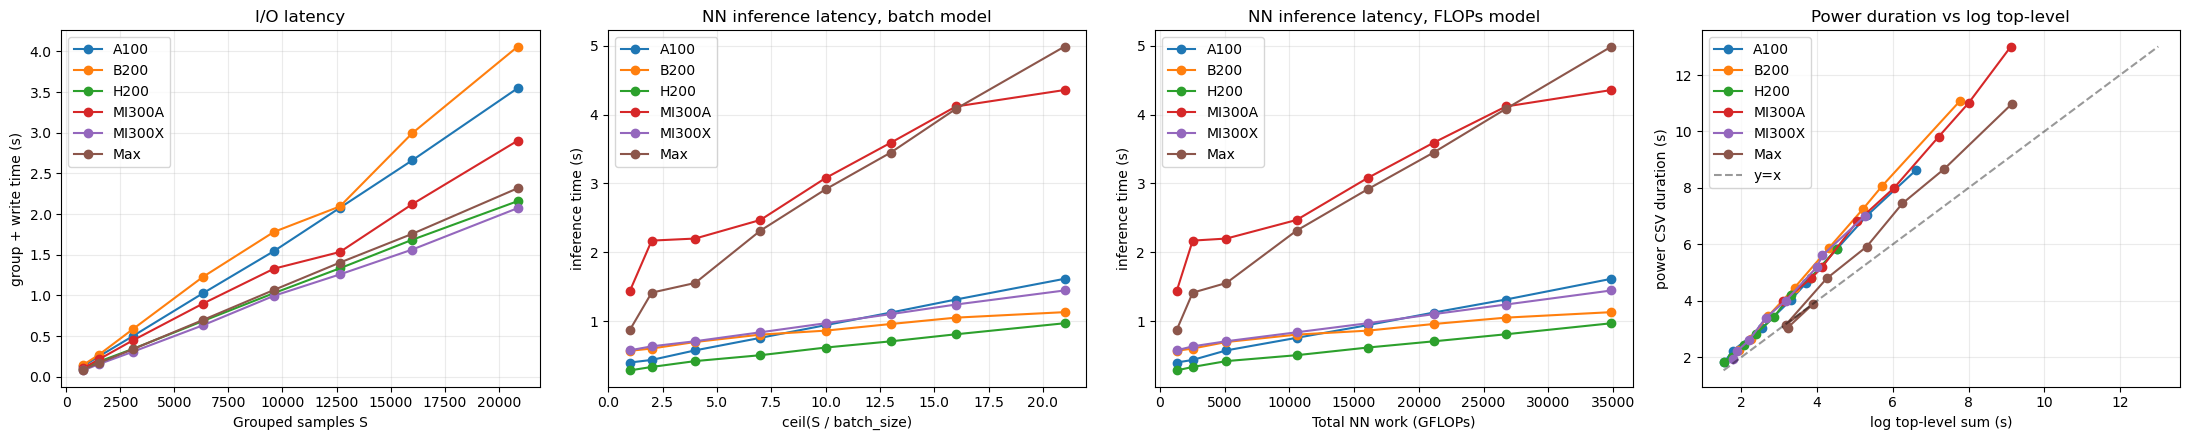

In [73]:
fig, axes = plt.subplots(1, 4, figsize=(22, 4.5))

for gpu, group in df.groupby("gpu"):
    group = group.sort_values("grouped_samples")
    axes[0].plot(group["grouped_samples"], group["io_core_s"], marker="o", label=gpu)
    axes[1].plot(group["num_batches"], group["inference_s"], marker="o", label=gpu)
    axes[2].plot(group["total_gflops"], group["inference_s"], marker="o", label=gpu)
    axes[3].plot(group["top_level_s"], group["power_duration_s"], marker="o", label=gpu)

axes[0].set_title("I/O latency")
axes[0].set_xlabel("Grouped samples S")
axes[0].set_ylabel("group + write time (s)")

axes[1].set_title("NN inference latency, batch model")
axes[1].set_xlabel("ceil(S / batch_size)")
axes[1].set_ylabel("inference time (s)")

axes[2].set_title("NN inference latency, FLOPs model")
axes[2].set_xlabel("Total NN work (GFLOPs)")
axes[2].set_ylabel("inference time (s)")

axes[3].set_title("Power duration vs log top-level")
axes[3].set_xlabel("log top-level sum (s)")
axes[3].set_ylabel("power CSV duration (s)")
mn = min(df["top_level_s"].min(), df["power_duration_s"].min())
mx = max(df["top_level_s"].max(), df["power_duration_s"].max())
axes[3].plot([mn, mx], [mn, mx], "k--", alpha=0.4, label="y=x")

for ax in axes:
    ax.grid(True, alpha=0.25)
    ax.legend()

plt.tight_layout()

## Export Coefficient Tables

This writes small CSV summaries into `modeling_exp/`. These are results, not synthetic input datasets.

In [74]:
raw_runs_csv = MODELING_ROOT / "modeling_runs_extracted.csv"
io_coeff_csv = MODELING_ROOT / "modeling_io_coefficients.csv"
infer_batch_coeff_csv = MODELING_ROOT / "modeling_inference_batch_coefficients.csv"
infer_flops_coeff_csv = MODELING_ROOT / "modeling_inference_flops_coefficients.csv"
power_summary_csv = MODELING_ROOT / "modeling_power_summary.csv"
power_phase_runs_csv = MODELING_ROOT / "modeling_power_phase_runs.csv"
power_model_coeff_csv = MODELING_ROOT / "modeling_power_model_coefficients.csv"
efficiency_estimates_csv = MODELING_ROOT / "modeling_efficiency_estimates.csv"

df.to_csv(raw_runs_csv, index=False)
io_coefficients_table.to_csv(io_coeff_csv, index=False)
inference_batch_coefficients_table.to_csv(infer_batch_coeff_csv, index=False)
inference_flops_coefficients_table.to_csv(infer_flops_coeff_csv, index=False)
power_summary.to_csv(power_summary_csv, index=False)
power_phase_df.to_csv(power_phase_runs_csv, index=False)
power_model_coefficients.to_csv(power_model_coeff_csv, index=False)
efficiency_estimates.to_csv(efficiency_estimates_csv, index=False)

# print("Saved files:")
# print(raw_runs_csv)
# print(io_coeff_csv)
# print(infer_batch_coeff_csv)
# print(infer_flops_coeff_csv)
# print(power_summary_csv)
# print(power_phase_runs_csv)
# print(power_model_coeff_csv)
# print(efficiency_estimates_csv)

print("\n=== I/O coefficients ===")
print(io_coefficients_table.to_string(index=False))

print("\n=== Inference coefficients: batch model ===")
print(inference_batch_coefficients_table.to_string(index=False))

print("\n=== Inference coefficients: FLOPs model ===")
print(inference_flops_coefficients_table.to_string(index=False))

print("\n=== Power summary ===")
print(power_summary.round(4).to_string(index=False))


=== I/O coefficients ===
   gpu  runs  alpha_group_us_per_valid_mean  alpha_group_us_per_valid_std  beta_write_us_per_grouped_mean  beta_write_us_per_grouped_std  gamma_io_us_per_grouped_mean  gamma_io_us_per_grouped_std  io_intercept_s  io_slope_s_per_grouped  io_slope_us_per_grouped  io_fit_r2  n
  A100     8                       129.9365                        3.2754                         34.6782                         2.4514                      164.6147                       3.0178         -0.0279                  0.0002                 168.8140     0.9993  8
  B200     8                        66.9137                        2.6457                        117.9732                         8.7845                      184.8870                       9.4444         -0.0304                  0.0002                 189.1220     0.9926  8
  H200     8                        81.3835                        7.5760                         29.2622                         0.7526             

In [ ]:
import csv
import math
from pathlib import Path

BASELINE_C = 4
BASELINE_N = 64
F_SAMPLE_GFLOPS_BY_N = {
    32: None,   # Current PtychoPINN decoder does not support N < 64 without architecture changes.
    64: 1.670,
    128: 3.774,
    256: 12.002,
}

def _modeling_root():
    cwd = Path.cwd()
    if cwd.name == 'modeling_exp':
        return cwd
    if (cwd / 'modeling_exp').exists():
        return cwd / 'modeling_exp'
    return Path('/home/zhong.zheng/PtychoPINN/modeling_exp')

ROOT = _modeling_root()

def read_rows(filename):
    with (ROOT / filename).open(newline='', encoding='utf-8') as handle:
        return list(csv.DictReader(handle))

def f(value, digits=4):
    try:
        x = float(value)
    except (TypeError, ValueError):
        return str(value)
    if math.isnan(x):
        return 'nan'
    return f'{x:.{digits}f}'

def beta_pixel_ns(io):
    if 'beta_write_ns_per_element_mean' in io and io['beta_write_ns_per_element_mean'] not in ('', None):
        return float(io['beta_write_ns_per_element_mean'])
    # Backward compatible conversion from the old N=64 per-grouped-sample coefficient.
    return float(io['beta_write_us_per_grouped_mean']) * 1000.0 / (BASELINE_C * BASELINE_N**2)

io_rows = {row['gpu']: row for row in read_rows('modeling_io_coefficients.csv')}
batch_rows = {row['gpu']: row for row in read_rows('modeling_inference_batch_coefficients.csv')}
flops_rows = {row['gpu']: row for row in read_rows('modeling_inference_flops_coefficients.csv')}
power_rows = {row['gpu']: row for row in read_rows('modeling_power_model_coefficients.csv')}
gpus = sorted(set(io_rows) | set(batch_rows) | set(flops_rows) | set(power_rows))

print('Notation:')
print('  D = dataset')
print('  V(D) = valid scan points')
print('  S(D) = grouped NN samples')
print(f'  C = grouped input channels/images, current C = {BASELINE_C}')
print('  N = diffraction image resolution')
print('  B = batch size')
print('  N_batch(D,B) = ceil(S(D) / B)')
print('  F(D,N) = S(D) * F_sample(N), so F(D,N) is measured in GFLOPs')
print('  F_sample(32) = unsupported by the current PtychoPINN decoder unless the architecture is changed')
for n, fs in F_SAMPLE_GFLOPS_BY_N.items():
    if fs is not None:
        print(f'  F_sample({n}) = {fs:.3f} GFLOPs/sample')
print('  E_total(D,N,B,G) = E_IO(D,N,G) + E_infer(D,N,B,G)')
print('  System GFLOPs/J = F(D,N) / E_total(D,N,B,G)')
print('')

for gpu in gpus:
    print('=' * 88)
    print(f'GPU: {gpu}')

    io = io_rows.get(gpu)
    batch = batch_rows.get(gpu)
    flops = flops_rows.get(gpu)
    power = power_rows.get(gpu)

    if io:
        beta_ns = beta_pixel_ns(io)
        print('I/O latency model, resolution-aware form:')
        print(f"  T_group(D,{gpu}) = {f(io['alpha_group_us_per_valid_mean'], 2)}e-6 * V(D) seconds")
        print(f"  beta_pixel({gpu}) = {beta_ns:.6f} ns per tensor element")
        print(f"  T_write(D,N,{gpu}) = {beta_ns:.6f}e-9 * S(D) * {BASELINE_C} * N^2 seconds")
        print(f"  T_IO(D,N,{gpu}) = T_group(D,{gpu}) + T_write(D,N,{gpu})")
        print(f"  Baseline N={BASELINE_N} equivalent: T_write(D,{BASELINE_N},{gpu}) = {f(io['beta_write_us_per_grouped_mean'], 2)}e-6 * S(D) seconds")
        if 'io_fit_r2' in io:
            print(f"  Baseline combined I/O fit quality: R2 = {f(io['io_fit_r2'], 4)}")

    if flops:
        B = flops['batch_size']
        print('Inference latency model, resolution-aware FLOPs form:')
        print('  F(D,N) = S(D) * F_sample(N)')
        for n, fs in F_SAMPLE_GFLOPS_BY_N.items():
            if fs is None:
                print(f'  N={n}: F_sample unavailable for the current implementation')
            else:
                print(f'  N={n}: F(D,{n}) = S(D) * {fs:.3f} GFLOPs')
        print(f"  Baseline fitted at N={BASELINE_N}:")
        print(f"  T_infer(D,N,B={B},{gpu}) ≈ {f(flops['A_flops_intercept_s'], 4)} + {f(flops['ms_per_tflop_work'], 2)}e-6 * F(D,N) seconds")
        print(f"  Equivalent baseline P_eff({gpu},B={B},N={BASELINE_N}) = {f(flops['P_eff_tflops'], 2)} TFLOP/s")
        print(f"  Fit quality at N={BASELINE_N}: R2 = {f(flops['flops_model_r2'], 4)}")
        print('  Note: for best accuracy at N=128/256, re-fit A_flops and P_eff with measurements at that N.')

    if power and batch:
        B = batch['batch_size']
        print('Power and system energy model:')
        print(f"  P_IO({gpu}) = {f(power['P_IO_w_median'], 2)} W")
        print(f"  P_infer(D,B={B},{gpu}) = {f(power['P_infer_intercept_w'], 2)} + {f(power['P_infer_slope_w_per_batch'], 2)} * ceil(S(D) / {B}) W")
        print(f"  P_infer fit quality: R2 = {f(power['P_infer_r2'], 4)}")
        print(f"  E_IO(D,N,{gpu}) = T_IO(D,N,{gpu}) * P_IO({gpu}) Joules")
        print(f"  E_infer(D,N,B={B},{gpu}) = T_infer(D,N,B={B},{gpu}) * P_infer(D,B={B},{gpu}) Joules")
        print(f"  E_total(D,N,B={B},{gpu}) = E_IO(D,N,{gpu}) + E_infer(D,N,B={B},{gpu}) Joules")
        print(f"  System GFLOPs/J(D,N,B={B},{gpu}) = F(D,N) / E_total(D,N,B={B},{gpu})")
    print('')
